# 📊 Notebook 1 — Análisis Exploratorio de Datos

**Dataset:** `Attributes.csv` — 30.141 imágenes de caras con 33 atributos binarios  
**Objetivo:** Entender la distribución del dataset antes de modelar

---
### ¿Qué veremos?
1. Cargar y explorar el dataset
2. Distribución de cada atributo (% de personas con ese rasgo)
3. Análisis del target (`attractive`)
4. Correlaciones entre atributos
5. Detección de duplicados y valores nulos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(' Librerías cargadas correctamente')

 Librerías cargadas correctamente


## 1. Carga del Dataset

In [3]:
# Cargar el CSV original
df = pd.read_csv('../data/01_raw/Attributes.csv')

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'\nPrimeras filas:')
df.head()

Filas:    30,141
Columnas: 34

Primeras filas:


,image_id,attractive,blurry_image,sharp_jawline,high_cheekbones,smiling,bald,receeding_hairline,long_hair,curly_hair,...,big_lips,sharp_nose,adult,old,mouth_open,male,double_chin,veil,wrinkle,chubby
0,00001.jpg,0,0,0,1,1,0,0,0,0,...,0,0,1,0,0,1,0,0,1,1
1,00002.jpg,1,0,0,1,1,0,0,1,0,...,0,0,1,0,1,0,0,0,0,0
2,00003.jpg,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,0,0
3,00004.jpg,1,0,1,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0
4,00005.jpg,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,1,0,0,1,1


In [4]:
# Tipos de datos y valores nulos
print('=== Info del Dataset ===')
print(f'Columnas: {list(df.columns)}')
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nDuplicados: {df.duplicated().sum():,}')

=== Info del Dataset ===
Columnas: ['image_id', 'attractive', 'blurry_image', 'sharp_jawline', 'high_cheekbones', 'smiling', 'bald', 'receeding_hairline', 'long_hair', 'curly_hair', 'grey_hair', 'black_hair', 'has_beard', 'patchy_beard', 'has_mustache', 'well_groomed', 'has_makeup', 'wearing_glasses', 'wearing_hat', 'clear_skin', 'dark_circles', 'oily_skin', 'thick_eyebrow', 'big_eyes', 'big_lips', 'sharp_nose', 'adult', 'old', 'mouth_open', 'male', 'double_chin', 'veil', 'wrinkle', 'chubby']

Valores nulos por columna:
image_id              0
attractive            0
blurry_image          0
sharp_jawline         0
high_cheekbones       0
smiling               0
bald                  0
receeding_hairline    0
long_hair             0
curly_hair            0
grey_hair             0
black_hair            0
has_beard             0
patchy_beard          0
has_mustache          0
well_groomed          0
has_makeup            0
wearing_glasses       0
wearing_hat           0
clear_skin        

## 2. Distribución de Atributos
¿Qué porcentaje de personas tiene cada atributo?

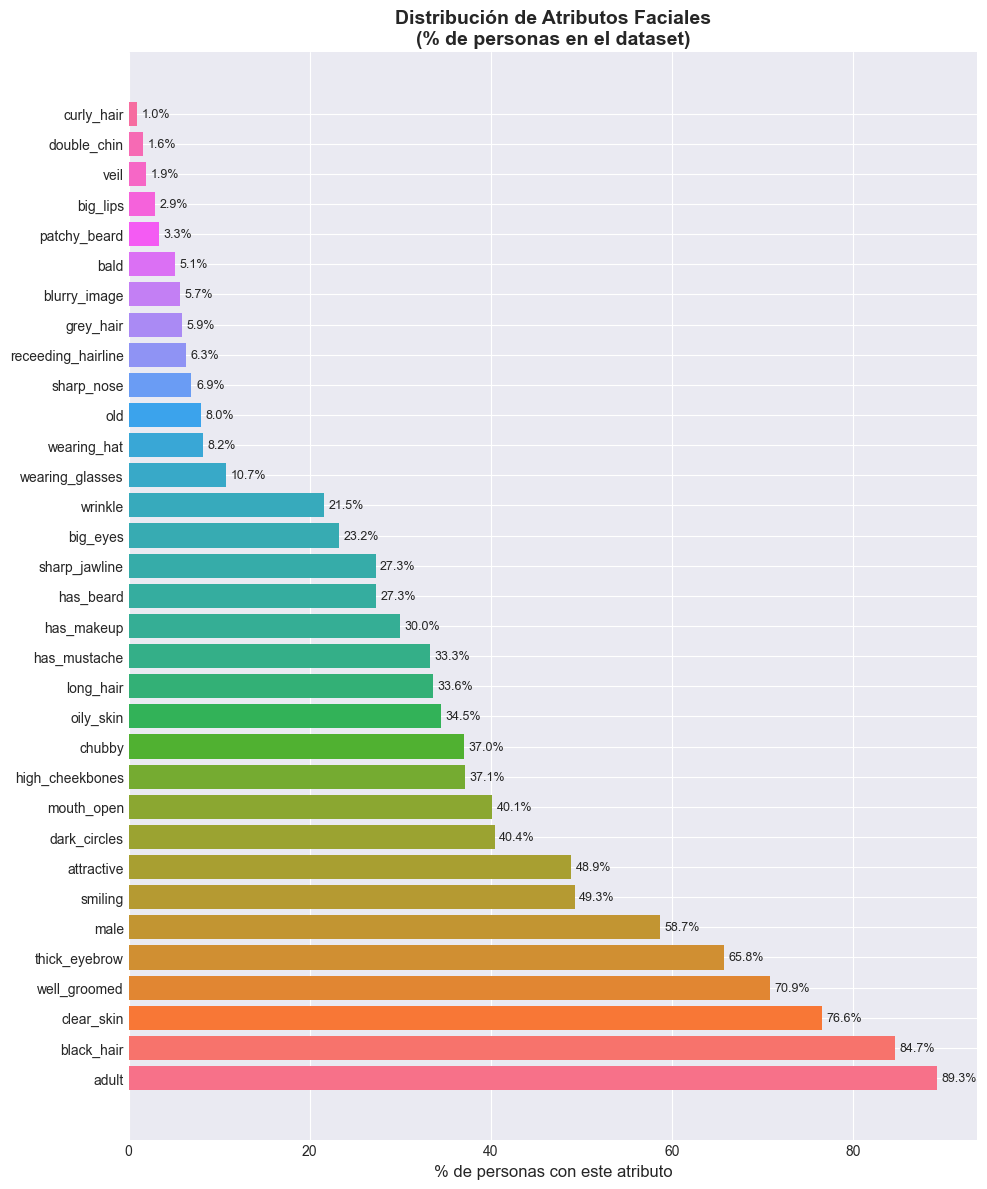


Top 5 más comunes: ['adult', 'black_hair', 'clear_skin', 'well_groomed', 'thick_eyebrow']
Top 5 menos comunes: ['patchy_beard', 'big_lips', 'veil', 'double_chin', 'curly_hair']


In [5]:
# Calcular porcentaje de cada atributo (sin image_id)
cols_binarias = [c for c in df.columns if c != 'image_id']
porcentajes = df[cols_binarias].mean().sort_values(ascending=False) * 100

# Gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(10, 12))
bars = ax.barh(porcentajes.index, porcentajes.values, color=sns.color_palette('husl', len(porcentajes)))
ax.set_xlabel('% de personas con este atributo', fontsize=12)
ax.set_title('Distribución de Atributos Faciales\n(% de personas en el dataset)', fontsize=14, fontweight='bold')

# Agregar valores en las barras
for bar, val in zip(bars, porcentajes.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/08_reporting/distribucion_atributos.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nTop 5 más comunes:', porcentajes.head(5).index.tolist())
print('Top 5 menos comunes:', porcentajes.tail(5).index.tolist())

## 3. Análisis del Target: `attractive`

In [8]:
# Balance de clases
conteo = df['attractive'].value_counts()
pct_atractivo = df['attractive'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de torta
axes[0].pie(conteo.values, labels=['No Atractivo (0)', 'Atractivo (1)'],
            autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'], startangle=90,
            textprops={'fontsize': 12})
axes[0].set_title('Balance de Clases\n(Variable Target: attractive)', fontsize=13, fontweight='bold')

# Gráfico de barras
axes[1].bar(['No Atractivo (0)', 'Atractivo (1)'], conteo.values,
            color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=0.8)
axes[1].set_ylabel('Cantidad de personas', fontsize=12)
axes[1].set_title('Cantidad por Clase', fontsize=13, fontweight='bold')
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/08_reporting/balance_clases.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nClase 0 (No atractivo): {conteo[0]:,} personas ({100-pct_atractivo:.1f}%)')
print(f'Clase 1 (Atractivo):    {conteo[1]:,} personas ({pct_atractivo:.1f}%)')
print(f'\n→ Dataset {'BALANCEADO ' if abs(pct_atractivo - 50) < 10 else 'DESBALANCEADO '} ({pct_atractivo:.1f}% positivos)')

SyntaxError: f-string: expecting '}' (1263100517.py, line 27)

## 4. Correlación de Atributos con el Target

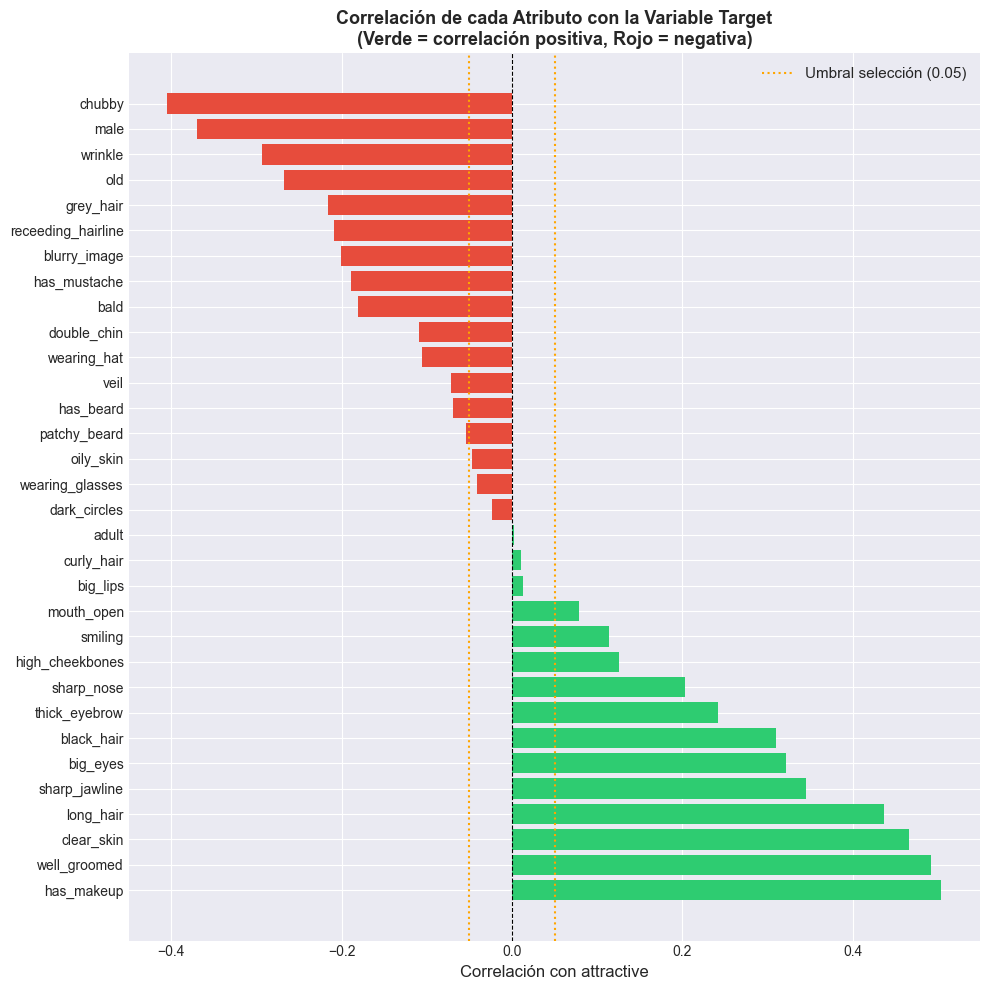

Top 5 correlación POSITIVA con attractive:
has_makeup       0.504
well_groomed     0.491
clear_skin       0.466
long_hair        0.437
sharp_jawline    0.345

Top 5 correlación NEGATIVA con attractive:
grey_hair   -0.216
old         -0.267
wrinkle     -0.293
male        -0.369
chubby      -0.404


In [9]:
# Correlación de cada feature con 'attractive'
cols_features = [c for c in df.columns if c not in ['image_id', 'attractive']]
correlaciones = df[cols_features].corrwith(df['attractive']).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colores = ['#2ECC71' if v > 0 else '#E74C3C' for v in correlaciones.values]
bars = ax.barh(correlaciones.index, correlaciones.values, color=colores)
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(x=0.05, color='orange', linewidth=1.5, linestyle=':', label='Umbral selección (0.05)')
ax.axvline(x=-0.05, color='orange', linewidth=1.5, linestyle=':')
ax.set_xlabel('Correlación con attractive', fontsize=12)
ax.set_title('Correlación de cada Atributo con la Variable Target\n(Verde = correlación positiva, Rojo = negativa)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/08_reporting/correlacion_target.png', dpi=120, bbox_inches='tight')
plt.show()

print('Top 5 correlación POSITIVA con attractive:')
print(correlaciones.head(5).round(3).to_string())
print('\nTop 5 correlación NEGATIVA con attractive:')
print(correlaciones.tail(5).round(3).to_string())

## 5. Mapa de Calor — Correlaciones entre todos los atributos

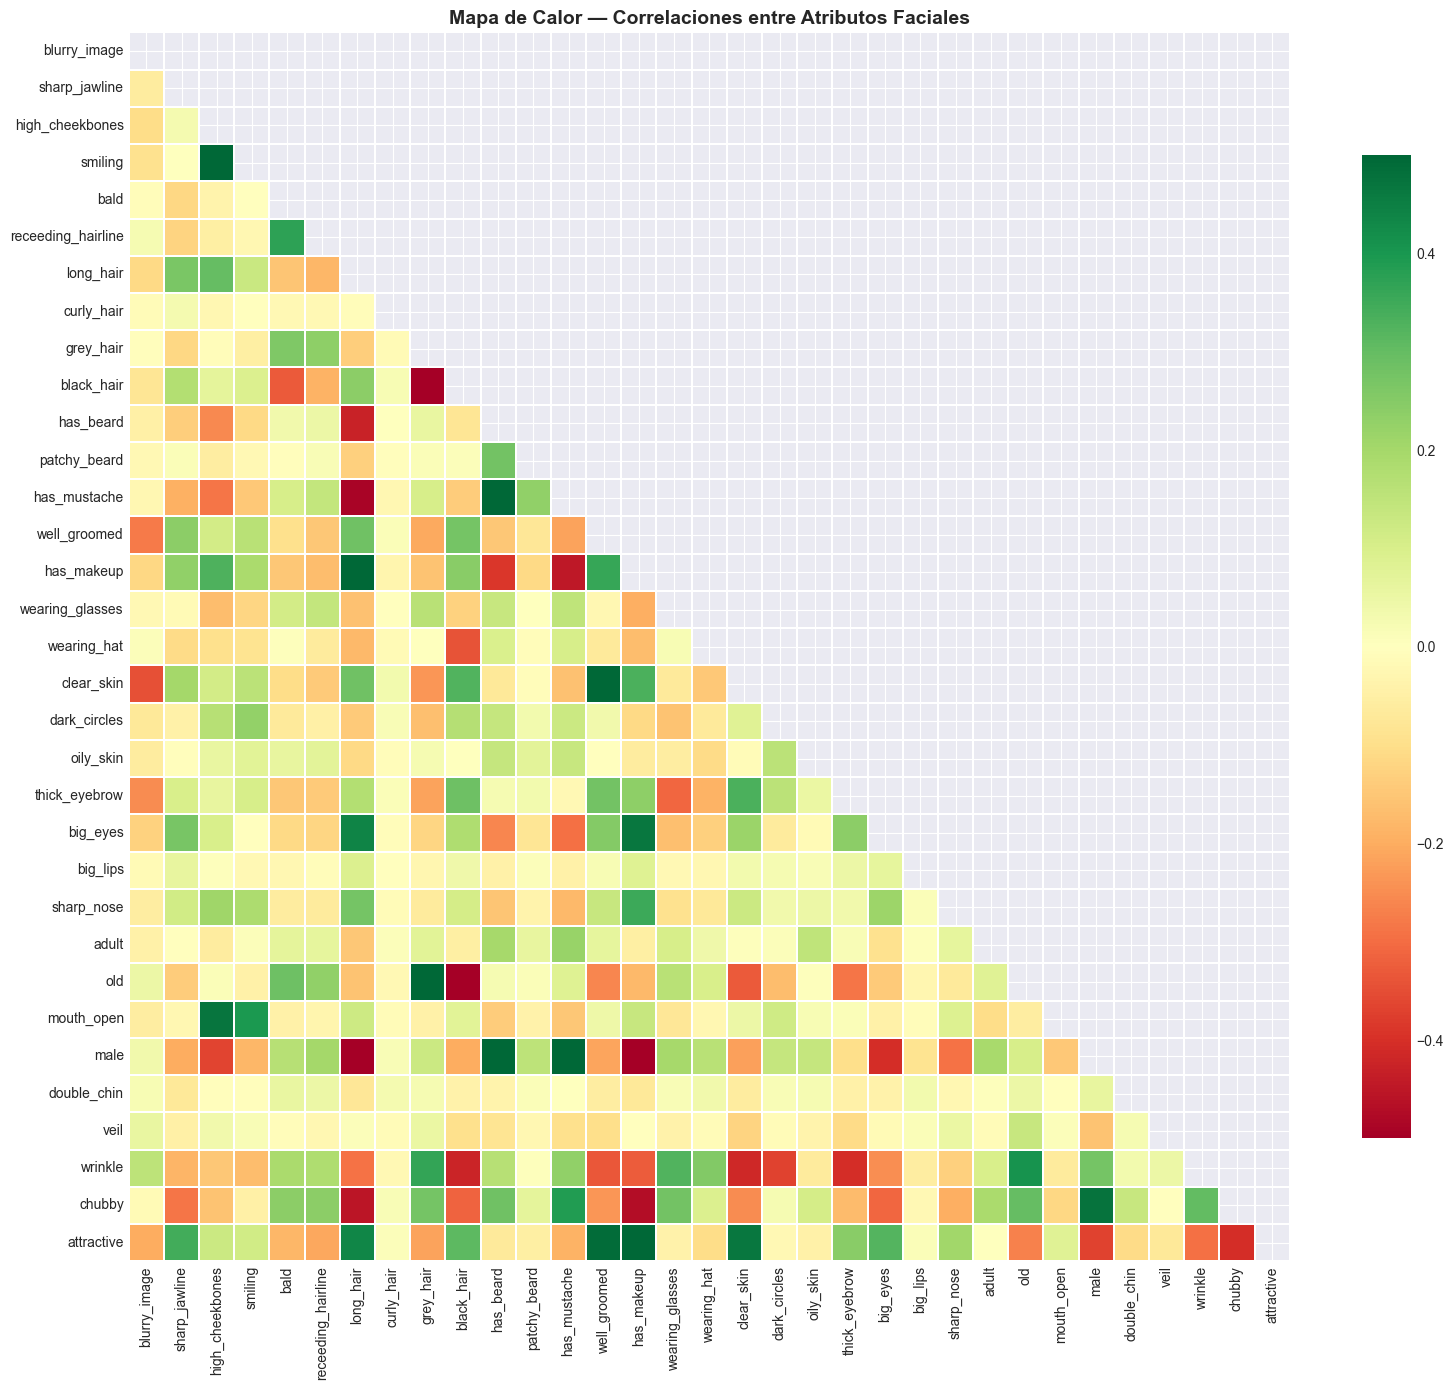

✅ Heatmap generado


In [10]:
# Heatmap de correlación
df_num = df[cols_features + ['attractive']]
corr_matrix = df_num.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdYlGn',
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Calor — Correlaciones entre Atributos Faciales', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/08_reporting/heatmap_correlaciones.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Heatmap generado')

## ✅ Conclusiones del Análisis Exploratorio

- El dataset tiene **30.141 imágenes** con **33 atributos binarios**
- Hay **17.000 duplicados** que se eliminan en el pipeline de limpieza
- El target `attractive` está **casi balanceado** (~49% positivo)
- Los atributos más correlacionados positivamente con `attractive` son: `smiling`, `high_cheekbones`, `clear_skin`
- Los más correlacionados negativamente: `chubby`, `double_chin`, `wrinkle`